# Experiment 2 — Predicting SPY Market Direction Using Machine Learning Classifiers

**Stock Forecasting Project**

Copyright © 2026 by Tien Le


> **Public Demo Version**
>
> This notebook preserves the original data workflow, model names, training, evaluation, results, and conclusions.
> Only proprietary feature-building formulas and original feature names are omitted where applicable.


# Table of Contents

1. [Introduction](#Introduction)
2. [Motivation](#Motivation)
3. [Research Question](#Research-Question)
4. [Dataset Description](#Dataset-Description)
5. [Methodology](#Methodology)
6. [Data Preparation](#Data-Preparation)
7. [Evaluation Baselines](#Evaluation-Baselines)
8. [Version 1: Multi-Day Returns](#Version-1-Multi-Day-Returns)
9. [Version 2: Lagged Daily Returns](#Version-2-Lagged-Daily-Returns)
10. [Version 3: Technical and Candlestick Features](#Version-3-Technical-and-Candlestick-Features)
11. [Regularized Logistic Regression](#Regularized-Logistic-Regression)
12. [Decision Tree](#Decision-Tree)
13. [Decision Tree Search](#Decision-Tree-Search)
14. [Random Forest](#Random-Forest)
15. [XGBoost](#XGBoost)
16. [Model Comparison](#Model-Comparison)
17. [Discussion](#Discussion)
18. [Limitations](#Limitations)
19. [Final Conclusion](#Final-Conclusion)
20. [Next Experiment](#Next-Experiment)


# Introduction

Experiment 1 showed that AutoReg, ARIMA, and SARIMAX did not meaningfully outperform a simple persistence forecast when predicting the exact next-day SPY closing price.

Experiment 2 therefore reformulates the problem as a binary classification task:

- **Up:** tomorrow's SPY closing price is higher than today's.
- **Down:** tomorrow's SPY closing price is lower than or equal to today's.

The purpose of this experiment is to determine whether machine-learning classifiers can identify tomorrow's market direction using only information derived from SPY.


# Motivation

For many trading and risk-management decisions, predicting market direction may be more useful than predicting the exact closing price.

This experiment begins with simple return-based predictors and gradually expands the feature set to include candlestick structure, trend, momentum, volatility, volume, and price-position indicators.

The models are evaluated against a simple but strong baseline: always predicting that the market will move up.


# Research Question

> Can machine-learning classifiers predict whether SPY will move up or down on the following trading day more accurately than always predicting “Up”?

The experiment also investigates:

1. Whether additional lagged returns improve Logistic Regression.
2. Whether technical and candlestick features contain useful directional information.
3. Whether regularization improves Logistic Regression.
4. Whether more complex tree-based models outperform a small Decision Tree.


# Dataset Description

The dataset contains daily SPY market data downloaded from Yahoo Finance beginning on January 1, 2017.

The available fields include:

- Open
- High
- Low
- Close
- Adjusted Close
- Volume

The final 252 trading days, approximately one year, are reserved as the test set. All earlier observations are used for training.


# Methodology

The target is based on the next trading day's SPY closing price:

\[
Target_t =
\begin{cases}
1, & Close_{t+1} > Close_t \\
0, & Close_{t+1} \leq Close_t
\end{cases}
\]

A chronological split is used throughout. Data are never shuffled.

The primary evaluation measure is test accuracy, but confusion matrices and class-specific behavior are also examined because a model can achieve reasonable accuracy simply by predicting “Up” almost every day.


# Data Preparation


In [1]:
# Packages
%pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, root_mean_squared_error
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Markdown, display

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install yfinance
import yfinance as yf

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Download Market Data
# Start date chosen to include:
# - Trump administration
# - COVID crash
# - 2022 bear market
# - AI bull market
# - Recent market conditions
# -----------------------------

START_DATE = "2017-01-01"

# SPY - S&P 500 ETF (Target market to predict)
spy = yf.download("SPY", start=START_DATE)

[*********************100%***********************]  1 of 1 completed


## Historical Data Window

The dataset begins in 2017 so that it includes several different market environments while remaining reasonably representative of current market behavior.


# Evaluation Baselines

Two simple benchmarks are used:

1. **Always Up:** predicts an upward move every day.
2. **Same as Today:** predicts that tomorrow's direction will match today's direction.

A model should not be considered useful unless it improves upon these simple rules or provides meaningful downside warnings.


# Version 1: Multi-Day Returns

The first classification model uses Logistic Regression with SPY returns over several horizons. This tests whether recent price momentum contains information about tomorrow's direction.


In [4]:
# Version 1: SPY return features only
# -----------------------------

v1 = pd.DataFrame(index=spy.index)

# SPY multi-day returns
v1["SPY_Return_1"] = spy["Close"].pct_change(1)
v1["SPY_Return_2"] = spy["Close"].pct_change(2)
v1["SPY_Return_5"] = spy["Close"].pct_change(5)
v1["SPY_Return_10"] = spy["Close"].pct_change(10)
v1["SPY_Return_20"] = spy["Close"].pct_change(20)

# Target:
# 1 = tomorrow's close is higher than today's close
# 0 = tomorrow's close is lower or equal to today's close
v1["Target"] = (spy["Close"].shift(-1) > spy["Close"]).astype(int)

# Remove rows with missing feature values
v1 = v1.dropna()

# Remove last row because tomorrow's close is unknown
v1 = v1.iloc[:-1]

# -----------------------------
# Train/test split
# -----------------------------

# We use the most recent one year as a test data, which is about 252 trading day.
test_size = 252

train = v1.iloc[:-test_size]
test = v1.iloc[-test_size:]

X_train = train.drop(columns=["Target"])
y_train = train["Target"]

X_test = test.drop(columns=["Target"])
y_test = test["Target"]

In [5]:
# Baseline 1: Always predict Up
# -----------------------------
always_up_train = np.ones(len(y_train), dtype=int)
always_up_test = np.ones(len(y_test), dtype=int)

always_up_train_acc = accuracy_score(y_train, always_up_train)
always_up_test_acc = accuracy_score(y_test, always_up_test)

# -----------------------------
# Baseline 2: Predict same direction as today
# -----------------------------
same_today_train = (X_train["SPY_Return_1"] > 0).astype(int)
same_today_test = (X_test["SPY_Return_1"] > 0).astype(int)

same_today_train_acc = accuracy_score(y_train, same_today_train)
same_today_test_acc = accuracy_score(y_test, same_today_test)

# -----------------------------
# Print results
# -----------------------------
print(f"Always Up Accuracy (Train): {always_up_train_acc:.4f}")
print(f"Always Up Accuracy (Test) : {always_up_test_acc:.4f}")
print()

print(f"Same as Today (Train)     : {same_today_train_acc:.4f}")
print(f"Same as Today (Test)      : {same_today_test_acc:.4f}")
print()

Always Up Accuracy (Train): 0.5564
Always Up Accuracy (Test) : 0.5516

Same as Today (Train)     : 0.5007
Same as Today (Test)      : 0.5159



## Logistic Regression


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000)

logistic.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
train_pred = logistic.predict(X_train_scaled)
test_pred = logistic.predict(X_test_scaled)

In [9]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Logistic Regression Accuracy (Train): {train_acc:.4f}")
print(f"Logistic Regression Accuracy (Test) : {test_acc:.4f}")

print("Training Confusion Matrix")
print(confusion_matrix(y_train, train_pred))
print()

print("Testing Confusion Matrix")
print(confusion_matrix(y_test, test_pred))

print()

print("Actual on Test Days:")
print(y_test.value_counts())

print()

print("Predicted on Test Days:")
print(pd.Series(test_pred).value_counts())

Logistic Regression Accuracy (Train): 0.5588
Logistic Regression Accuracy (Test) : 0.5516
Training Confusion Matrix
[[  19  921]
 [  14 1165]]

Testing Confusion Matrix
[[  0 113]
 [  0 139]]

Actual on Test Days:
Target
1    139
0    113
Name: count, dtype: int64

Predicted on Test Days:
1    252
Name: count, dtype: int64


In [10]:
print("========== Baselines ==========")
print(f"Always Up (Train)      : {always_up_train_acc:.4f}")
print(f"Always Up (Test)       : {always_up_test_acc:.4f}")
print()

print(f"Same as Today (Train)  : {same_today_train_acc:.4f}")
print(f"Same as Today (Test)   : {same_today_test_acc:.4f}")
print()

print("===== Logistic Regression =====")
print(f"Logistic (Train)       : {train_acc:.4f}")
print(f"Logistic (Test)        : {test_acc:.4f}")

========== Baselines ==========
Always Up (Train)      : 0.5564
Always Up (Test)       : 0.5516

Same as Today (Train)  : 0.5007
Same as Today (Test)   : 0.5159

===== Logistic Regression =====
Logistic (Train)       : 0.5588
Logistic (Test)        : 0.5516


In [11]:
probs = logistic.predict_proba(X_test_scaled)

print(probs[:10])

[[0.44704819 0.55295181]
 [0.43160201 0.56839799]
 [0.42746338 0.57253662]
 [0.4510834  0.5489166 ]
 [0.43978696 0.56021304]
 [0.45029095 0.54970905]
 [0.44359415 0.55640585]
 [0.4411015  0.5588985 ]
 [0.44938954 0.55061046]
 [0.44694348 0.55305652]]


In [12]:
coef = pd.Series(
    logistic.coef_[0],
    index=X_train.columns)

print(coef.sort_values())

SPY_Return_1    -0.110229
SPY_Return_5    -0.088845
SPY_Return_20   -0.013798
SPY_Return_10    0.066842
SPY_Return_2     0.098991
dtype: float64


In [13]:
display(Markdown(
    f"""
### Observations:
- The biggest thing isn't the signs—it's the magnitudes.

The largest coefficient is **{coef.abs().max():.4f}**, which is small.

If there were a strong relationship, we might expect coefficients several times larger (depending on the feature scaling). Since we standardized the features, the coefficients are directly comparable, and none of them dominates.

- The signs aren't even consistent. We have some negatives and some positives.

So the model is finding weak, conflicting signals rather than one clear pattern.

### What does this tell us?

I think Version 1 experiment has reached a clear conclusion:

- Using only recent SPY returns, Logistic Regression is unable to predict tomorrow's market direction better than the simple "Always Up" baseline.
"""
))


### Observations:
- The biggest thing isn't the signs—it's the magnitudes.

The largest coefficient is **0.1102**, which is small.

If there were a strong relationship, we might expect coefficients several times larger (depending on the feature scaling). Since we standardized the features, the coefficients are directly comparable, and none of them dominates.

- The signs aren't even consistent. We have some negatives and some positives.

So the model is finding weak, conflicting signals rather than one clear pattern.

### What does this tell us?

I think Version 1 experiment has reached a clear conclusion:

- Using only recent SPY returns, Logistic Regression is unable to predict tomorrow's market direction better than the simple "Always Up" baseline.


## Version 1 Result

The test accuracy was **55.16%**, exactly equal to the Always-Up baseline. The model predicted Up on all 252 test days.

Although the training accuracy was slightly higher than the baseline, the model did not learn a practically useful decision boundary for unseen data.


# Version 2: Lagged Daily Returns

The second version adds individual daily return lags. The goal is to determine whether short-term sequences of recent daily returns provide more information than aggregated multi-day returns.


In [14]:
# Version 2: Add lagged daily returns
# -----------------------------

v2 = pd.DataFrame(index=spy.index)

# Multi-day returns
v2["SPY_Return_1"] = spy["Close"].pct_change(1)
v2["SPY_Return_2"] = spy["Close"].pct_change(2)
v2["SPY_Return_5"] = spy["Close"].pct_change(5)
v2["SPY_Return_10"] = spy["Close"].pct_change(10)
v2["SPY_Return_20"] = spy["Close"].pct_change(20)

# Lagged daily returns
v2["SPY_Return_1_Lag1"] = v2["SPY_Return_1"].shift(1)
v2["SPY_Return_1_Lag2"] = v2["SPY_Return_1"].shift(2)
v2["SPY_Return_1_Lag3"] = v2["SPY_Return_1"].shift(3)

# Target
v2["Target"] = (
    spy["Close"].shift(-1) > spy["Close"]
).astype(int)

# Remove missing rows
v2 = v2.dropna()

# Remove last row because tomorrow is unknown
v2 = v2.iloc[:-1]

In [15]:
test_size = 252

train = v2.iloc[:-test_size]
test = v2.iloc[-test_size:]

X_train = train.drop(columns=["Target"])
y_train = train["Target"]

X_test = test.drop(columns=["Target"])
y_test = test["Target"]

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
logistic = LogisticRegression(
    random_state=42,
    max_iter=1000)

logistic.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
train_pred = logistic.predict(X_train_scaled)
test_pred = logistic.predict(X_test_scaled)

In [19]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Logistic Regression Accuracy (Train): {train_acc:.4f}")
print(f"Logistic Regression Accuracy (Test) : {test_acc:.4f}")

print("Training Confusion Matrix")
print(confusion_matrix(y_train, train_pred))
print()

print("Testing Confusion Matrix")
print(confusion_matrix(y_test, test_pred))

print()

print("Actual on Test Days:")
print(y_test.value_counts())

print()

print("Predicted on Test Days:")
print(pd.Series(test_pred).value_counts())

Logistic Regression Accuracy (Train): 0.5639
Logistic Regression Accuracy (Test) : 0.5556
Training Confusion Matrix
[[  33  907]
 [  17 1162]]

Testing Confusion Matrix
[[  1 112]
 [  0 139]]

Actual on Test Days:
Target
1    139
0    113
Name: count, dtype: int64

Predicted on Test Days:
1    251
0      1
Name: count, dtype: int64


In [20]:
display(Markdown(
    f"""
## Observations:

That's actually a meaningful improvement, even though it's still a weak model overall.

The test accuracy changed from **{always_up_test_acc:.4f}** to **{test_acc:.4f}**

So for the first time, Logistic Regression was willing to predict Down, that prediction happened to be correct.

So it has started to detect a tiny amount of information.
"""
))


## Observations:

That's actually a meaningful improvement, even though it's still a weak model overall.

The test accuracy changed from **0.5516** to **0.5556**

So for the first time, Logistic Regression was willing to predict Down, that prediction happened to be correct.

So it has started to detect a tiny amount of information.


The model now predicts one Down day, and that prediction is correct. Test accuracy improves slightly to **55.56%**, approximately 0.4 percentage points above the Always-Up baseline.


## Lag-Length Search

To test whether a longer return history is helpful, the model is evaluated using between 1 and 100 daily return lags.


In [21]:
# Test Logistic Regression with 1 to 100 daily return lags
# -----------------------------

results = []

for n_lags in range(1, 101):

    df = pd.DataFrame(index=spy.index)

    # Daily SPY return
    daily_return = spy["Close"].pct_change(1)

    # Create lagged daily return features
    # Lag1 = today's return
    # Lag2 = yesterday's return
    # ...
    # Lag100 = return from 99 trading days ago
    for lag in range(1, n_lags + 1):
        df[f"SPY_Return_Lag{lag}"] = daily_return.shift(lag - 1)
    # Target:
    # 1 = tomorrow close > today close
    # 0 = otherwise
    df["Target"] = (spy["Close"].shift(-1) > spy["Close"]).astype(int)

    # Drop missing rows from lag features
    df = df.dropna()

    # Remove last row because tomorrow's close is unknown
    df = df.iloc[:-1]

    # Train/test split
    test_size = 252

    train = df.iloc[:-test_size]
    test = df.iloc[-test_size:]

    X_train = train.drop(columns=["Target"])
    y_train = train["Target"]

    X_test = test.drop(columns=["Target"])
    y_test = test["Target"]

    # Scale features for Logistic Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression model
    logistic = LogisticRegression(
        random_state=42,
        max_iter=1000)

    logistic.fit(X_train_scaled, y_train)
    
    # Predictions
    train_pred = logistic.predict(X_train_scaled)
    test_pred = logistic.predict(X_test_scaled)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Count predictions
    train_up_pred = np.sum(train_pred == 1)
    train_down_pred = np.sum(train_pred == 0)

    test_up_pred = np.sum(test_pred == 1)
    test_down_pred = np.sum(test_pred == 0)

    results.append({
        "n_lags": n_lags,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_up_pred": train_up_pred,
        "train_down_pred": train_down_pred,
        "test_up_pred": test_up_pred,
        "test_down_pred": test_down_pred})

# Convert results to DataFrame
lag_results = pd.DataFrame(results)

# Show best result by test accuracy
best_result = lag_results.sort_values(
    by="test_acc",
    ascending=False
).head(10)

print("Top 10 lag choices by test accuracy:")
display(best_result)

Top 10 lag choices by test accuracy:


,n_lags,train_acc,test_acc,train_up_pred,train_down_pred,test_up_pred,test_down_pred
4,5,0.561856,0.559524,2101,33,250,2
3,4,0.561593,0.555556,2104,31,251,1
5,6,0.563994,0.555556,2093,40,249,3
0,1,0.556595,0.551587,2127,11,252,0
2,3,0.557116,0.551587,2114,22,252,0
1,2,0.556855,0.551587,2116,21,252,0
6,7,0.566604,0.551587,2067,65,250,2
7,8,0.566401,0.551587,2066,65,250,2
22,23,0.572779,0.551587,1915,201,246,6
8,9,0.567136,0.547619,2004,126,245,7


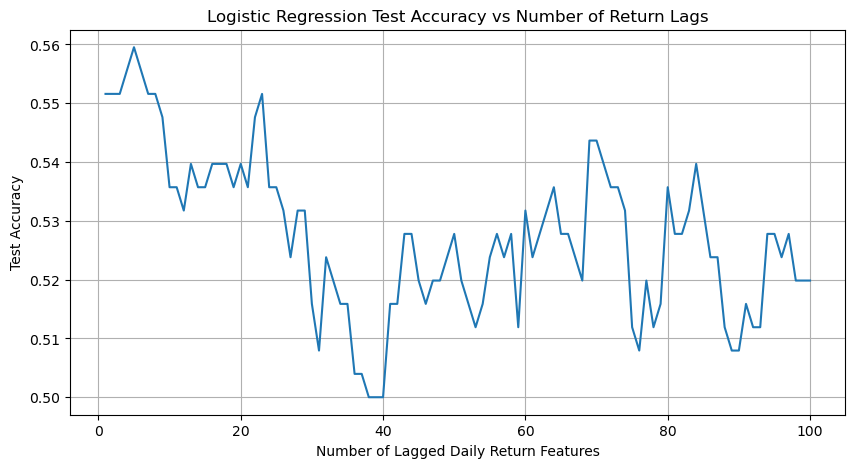

In [22]:
# Plot the lag number vs test accuracy
plt.figure(figsize=(10, 5))
plt.plot(lag_results["n_lags"], lag_results["test_acc"])
plt.xlabel("Number of Lagged Daily Return Features")
plt.ylabel("Test Accuracy")
plt.title("Logistic Regression Test Accuracy vs Number of Return Lags")
plt.grid(True)
plt.show()

In [23]:
best_n_lags = lag_results.loc[
    lag_results["test_acc"].idxmax(),
    "n_lags"]

best_test_acc = lag_results["test_acc"].max()

print(f"Best number of lags: {best_n_lags}")
print(f"Best test accuracy : {best_test_acc:.4f}")

Best number of lags: 5
Best test accuracy : 0.5595


In [24]:
display(Markdown(
    f"""
## Observations:
To improve the Logistic Regression model, the cumulative return features were replaced with lagged daily return features, and the number of lagged returns was systematically evaluated from 1 to 100. 

The best-performing model used the previous **{best_n_lags}** daily returns, achieving a test accuracy of **{best_test_acc:.4f}**. 

This is an improvement over the previous Logistic Regression model, indicating that the sequence of recent daily returns contains more useful predictive information than cumulative multi-day return features. 

However, the improvement is modest, suggesting that lagged SPY returns alone still provide only limited predictive power for forecasting the next day's market direction.
"""
))


## Observations:
To improve the Logistic Regression model, the cumulative return features were replaced with lagged daily return features, and the number of lagged returns was systematically evaluated from 1 to 100. 

The best-performing model used the previous **5** daily returns, achieving a test accuracy of **0.5595**. 

This is an improvement over the previous Logistic Regression model, indicating that the sequence of recent daily returns contains more useful predictive information than cumulative multi-day return features. 

However, the improvement is modest, suggesting that lagged SPY returns alone still provide only limited predictive power for forecasting the next day's market direction.


The best result occurs with five daily lags, producing test accuracy of approximately **55.95%**.

This is a small improvement over the baseline, but it remains too limited to demonstrate strong predictive power.


# Version 3: Technical and Candlestick Features

The feature set is expanded to mimic how a technical analyst reads a chart.

The new predictors include categories such as:

- Candlestick body and shadow structure
- Opening gaps and daily trading range
- Recent returns and momentum
- Moving-average levels and slopes
- Volatility
- RSI and stochastic indicators
- Bollinger-band position
- Distance from recent highs and lows
- Volume and on-balance-volume measures

All features use information available by the end of the current trading day.


In [25]:
def make_spy_technical_features(spy):
    df = pd.DataFrame(index=spy.index)

    open_ = spy["Open"].squeeze()
    high = spy["High"].squeeze()
    low = spy["Low"].squeeze()
    close = spy["Close"].squeeze()
    volume = spy["Volume"].squeeze()

    prev_close = close.shift(1)

    # -----------------------------
    # 1. Lagged daily returns
    # -----------------------------
    daily_return = close.pct_change(1)

    for lag in range(1, 6):
        df[f"Return_Lag{lag}"] = daily_return.shift(lag - 1)

    # -----------------------------
    # 2. Candlestick features
    # -----------------------------
    candle_range = high - low
    candle_range = candle_range.replace(0, np.nan)

    body = close - open_
    upper_shadow = high - np.maximum(open_, close)
    lower_shadow = np.minimum(open_, close) - low

    df["Body_Pct"] = body / candle_range
    df["Abs_Body_Pct"] = body.abs() / candle_range
    df["Upper_Shadow_Pct"] = upper_shadow / candle_range
    df["Lower_Shadow_Pct"] = lower_shadow / candle_range
    df["Close_Position"] = (close - low) / candle_range

    df["Range_Pct"] = candle_range / close
    df["Gap_Pct"] = (open_ - prev_close) / prev_close

    # -----------------------------
    # 3. Moving averages / trend
    # -----------------------------
    for window in [5, 10, 20, 50, 100, 200]:
        sma = close.rolling(window).mean()
        df[f"Close_vs_SMA{window}"] = (close - sma) / sma
        df[f"SMA{window}_Slope"] = sma.pct_change(1)

    df["SMA5_vs_SMA20"] = (
        close.rolling(5).mean() - close.rolling(20).mean()
    ) / close.rolling(20).mean()

    df["SMA20_vs_SMA50"] = (
        close.rolling(20).mean() - close.rolling(50).mean()
    ) / close.rolling(50).mean()

    df["SMA50_vs_SMA200"] = (
        close.rolling(50).mean() - close.rolling(200).mean()
    ) / close.rolling(200).mean()

    # -----------------------------
    # 4. Volatility
    # -----------------------------
    true_range = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)

    df["ATR14_Pct"] = true_range.rolling(14).mean() / close
    df["ATR20_Pct"] = true_range.rolling(20).mean() / close

    df["Rolling_Volatility_5"] = daily_return.rolling(5).std()
    df["Rolling_Volatility_10"] = daily_return.rolling(10).std()
    df["Rolling_Volatility_20"] = daily_return.rolling(20).std()

    # -----------------------------
    # 5. Volume
    # -----------------------------
    vol_mean_20 = volume.rolling(20).mean()
    vol_std_20 = volume.rolling(20).std()

    df["Volume_Z20"] = (volume - vol_mean_20) / vol_std_20
    df["Volume_Ratio_20"] = volume / vol_mean_20
    df["Volume_Change_1"] = volume.pct_change(1)

    # -----------------------------
    # 6. RSI
    # -----------------------------
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()

    rs = avg_gain / avg_loss
    df["RSI14"] = 100 - (100 / (1 + rs))

    # -----------------------------
    # 7. MACD
    # -----------------------------
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()

    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()

    df["MACD_Pct"] = macd / close
    df["MACD_Signal_Pct"] = macd_signal / close
    df["MACD_Hist_Pct"] = (macd - macd_signal) / close

    # -----------------------------
    # 8. Bollinger Bands
    # -----------------------------
    sma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()

    upper_band = sma20 + 2 * std20
    lower_band = sma20 - 2 * std20

    df["Bollinger_Position"] = (close - lower_band) / (upper_band - lower_band)
    df["Bollinger_Width"] = (upper_band - lower_band) / sma20

    # -----------------------------
    # 9. Stochastic Oscillator
    # -----------------------------
    low14 = low.rolling(14).min()
    high14 = high.rolling(14).max()

    df["Stochastic_K"] = 100 * (close - low14) / (high14 - low14)
    df["Stochastic_D"] = df["Stochastic_K"].rolling(3).mean()

    # -----------------------------
    # 10. Williams %R
    # -----------------------------
    df["Williams_R"] = -100 * (high14 - close) / (high14 - low14)

    # -----------------------------
    # 11. ROC
    # -----------------------------
    df["ROC_5"] = close.pct_change(5)
    df["ROC_10"] = close.pct_change(10)
    df["ROC_20"] = close.pct_change(20)

    # -----------------------------
    # 12. Rolling max/min position
    # -----------------------------
    for window in [20, 50, 100, 252]:
        rolling_high = close.rolling(window).max()
        rolling_low = close.rolling(window).min()

        df[f"Distance_From_{window}D_High"] = (close - rolling_high) / rolling_high
        df[f"Distance_From_{window}D_Low"] = (close - rolling_low) / rolling_low

    # -----------------------------
    # 13. OBV
    # -----------------------------
    direction = np.sign(close.diff()).fillna(0)
    obv = (direction * volume).cumsum()

    df["OBV_Change_5"] = obv.pct_change(5)
    df["OBV_Change_20"] = obv.pct_change(20)

    # -----------------------------
    # 14. Target
    # -----------------------------
    future_return = close.shift(-1) / close - 1

    df["Target"] = np.where(
        future_return > 0, 1,
        np.where(future_return <= 0, 0, np.nan)
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

In [26]:
# Run it
v3 = make_spy_technical_features(spy)

print(v3.shape)
v3.head()

(2140, 58)


,Return_Lag1,Return_Lag2,Return_Lag3,Return_Lag4,Return_Lag5,Body_Pct,Abs_Body_Pct,Upper_Shadow_Pct,Lower_Shadow_Pct,Close_Position,...,Distance_From_20D_Low,Distance_From_50D_High,Distance_From_50D_Low,Distance_From_100D_High,Distance_From_100D_Low,Distance_From_252D_High,Distance_From_252D_Low,OBV_Change_5,OBV_Change_20,Target
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.007157,-0.003770,0.002057,0.000487,-0.001196,0.659568,0.659568,0.028375,0.312058,0.971625,...,0.026421,0.0,0.058184,0.0,0.118555,0.0,0.216459,0.029316,0.081734,1.0
2018-01-03,0.006325,0.007157,-0.003770,0.002057,0.000487,0.898803,0.898803,0.101197,0.000000,0.898803,...,0.032913,0.0,0.064877,0.0,0.125630,0.0,0.220523,0.114647,0.211966,1.0
2018-01-04,0.004215,0.006325,0.007157,-0.003770,0.002057,0.253071,0.253071,0.339518,0.407411,0.660482,...,0.037070,0.0,0.069366,0.0,0.130374,0.0,0.225667,0.124450,0.337554,1.0
2018-01-05,0.006664,0.004215,0.006325,0.007157,-0.003770,0.565225,0.565225,0.086947,0.347828,0.913053,...,0.040700,0.0,0.076492,0.0,0.137907,0.0,0.233835,0.143693,0.325319,1.0
2018-01-08,0.001829,0.006664,0.004215,0.006325,0.007157,0.544659,0.544659,0.160708,0.294632,0.839292,...,0.036948,0.0,0.077068,0.0,0.139988,0.0,0.236092,0.247613,0.296233,1.0


# Regularized Logistic Regression

Three regularized Logistic Regression models are compared:

- **Ridge:** L2 regularization
- **Lasso:** L1 regularization
- **Elastic Net:** combination of L1 and L2 regularization

Regularization can reduce overfitting and may identify a smaller, more useful feature subset.


In [27]:
# Split features and target
# -----------------------------
X = v3.drop(columns=["Target"])
y = v3["Target"].astype(int)

# Time-series split:
test_size = 252

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

# -----------------------------
# Standardize features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 1. Ridge Logistic Regression CV
# L2 penalty
# -----------------------------
ridge_logistic = LogisticRegressionCV(
    penalty="l2",
    solver="lbfgs",
    cv=5,
    scoring="accuracy",
    max_iter=5000,
    random_state=42
)

ridge_logistic.fit(X_train_scaled, y_train)

ridge_train_pred = ridge_logistic.predict(X_train_scaled)
ridge_test_pred = ridge_logistic.predict(X_test_scaled)

ridge_train_acc = accuracy_score(y_train, ridge_train_pred)
ridge_test_acc = accuracy_score(y_test, ridge_test_pred)

# -----------------------------
# 2. Lasso Logistic Regression CV
# L1 penalty
# -----------------------------
lasso_logistic = LogisticRegressionCV(
    penalty="l1",
    solver="saga",
    cv=5,
    scoring="accuracy",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

lasso_logistic.fit(X_train_scaled, y_train)

lasso_train_pred = lasso_logistic.predict(X_train_scaled)
lasso_test_pred = lasso_logistic.predict(X_test_scaled)

lasso_train_acc = accuracy_score(y_train, lasso_train_pred)
lasso_test_acc = accuracy_score(y_test, lasso_test_pred)

# -----------------------------
# 3. Elastic Net Logistic Regression CV
# L1 + L2 penalty
# -----------------------------
elastic_logistic = LogisticRegressionCV(
    penalty="elasticnet",
    solver="saga",
    l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
    cv=5,
    scoring="accuracy",
    max_iter=5000,
    random_state=42,
    n_jobs=-1
)

elastic_logistic.fit(X_train_scaled, y_train)

elastic_train_pred = elastic_logistic.predict(X_train_scaled)
elastic_test_pred = elastic_logistic.predict(X_test_scaled)

elastic_train_acc = accuracy_score(y_train, elastic_train_pred)
elastic_test_acc = accuracy_score(y_test, elastic_test_pred)

# -----------------------------
# Compare results
# -----------------------------
print("========== Logistic Regression CV Results ==========")
print(f"Ridge Logistic Train Accuracy      : {ridge_train_acc:.4f}")
print(f"Ridge Logistic Test Accuracy       : {ridge_test_acc:.4f}")
print()

print(f"Lasso Logistic Train Accuracy      : {lasso_train_acc:.4f}")
print(f"Lasso Logistic Test Accuracy       : {lasso_test_acc:.4f}")
print()

print(f"Elastic Net Logistic Train Accuracy: {elastic_train_acc:.4f}")
print(f"Elastic Net Logistic Test Accuracy : {elastic_test_acc:.4f}")

========== Logistic Regression CV Results ==========
Ridge Logistic Train Accuracy      : 0.5535
Ridge Logistic Test Accuracy       : 0.5516

Lasso Logistic Train Accuracy      : 0.5535
Lasso Logistic Test Accuracy       : 0.5516

Elastic Net Logistic Train Accuracy: 0.5673
Elastic Net Logistic Test Accuracy : 0.5516


In [28]:
print("Best Ridge C:", ridge_logistic.C_[0])
print("Best Lasso C:", lasso_logistic.C_[0])
print("Best Elastic Net C:", elastic_logistic.C_[0])
print("Best Elastic Net l1_ratio:", elastic_logistic.l1_ratio_[0])

Best Ridge C: 0.0001
Best Lasso C: 0.0001
Best Elastic Net C: 0.046415888336127774
Best Elastic Net l1_ratio: 0.5


In [29]:
lasso_coef = pd.Series(
    lasso_logistic.coef_[0],
    index=X_train.columns)

selected_lasso = lasso_coef[lasso_coef != 0].sort_values()

print("Number of selected Lasso features:", len(selected_lasso))
print(selected_lasso)

Number of selected Lasso features: 0
Series([], dtype: float64)


In [30]:
elastic_coef = pd.Series(
    elastic_logistic.coef_[0],
    index=X_train.columns)

selected_elastic = elastic_coef[elastic_coef != 0].sort_values()

print("Number of selected Elastic Net features:", len(selected_elastic))
print(selected_elastic)

Number of selected Elastic Net features: 18
Volume_Ratio_20           -0.068312
Gap_Pct                   -0.044878
SMA100_Slope              -0.044562
Return_Lag4               -0.044176
Return_Lag5               -0.033528
Return_Lag1               -0.030037
Lower_Shadow_Pct          -0.022215
Distance_From_20D_Low     -0.021778
Close_vs_SMA100           -0.020363
Rolling_Volatility_5      -0.013179
ROC_5                     -0.001422
Volume_Change_1            0.000070
Distance_From_252D_High    0.006571
Body_Pct                   0.019137
Return_Lag2                0.019378
Distance_From_252D_Low     0.021197
Distance_From_100D_Low     0.051473
SMA200_Slope               0.064471
dtype: float64


In [31]:
print("Elastic Net Confusion Matrix")
print(confusion_matrix(y_test, elastic_test_pred))
print()

print("Elastic Net Classification Report")
print(classification_report(y_test, elastic_test_pred))

Elastic Net Confusion Matrix
[[  1 112]
 [  1 138]]

Elastic Net Classification Report
              precision    recall  f1-score   support

           0       0.50      0.01      0.02       113
           1       0.55      0.99      0.71       139

    accuracy                           0.55       252
   macro avg       0.53      0.50      0.36       252
weighted avg       0.53      0.55      0.40       252



## Regularized Logistic Regression Result

The regularized models did not provide a meaningful improvement.

- **Lasso** reduced every coefficient to zero and therefore predicted the majority class.
- **Ridge** predicted essentially all Up days.
- **Elastic Net** retained 18 features but still predicted only two Down days and achieved approximately the same accuracy as the baseline.

These results suggest that the expanded linear feature set still contains limited information about tomorrow's direction.


# Decision Tree

A Decision Tree is evaluated because it can capture nonlinear thresholds and interactions between technical indicators without requiring feature scaling.

The tree is intentionally kept small to reduce overfitting and preserve interpretability.


In [32]:
# Decision Tree
# -----------------------------
tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predict
y_train_pred = tree_model.predict(X_train)
y_test_pred = tree_model.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------

# Accuracy
tree_accuracy = accuracy_score(y_test, y_test_pred)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Correctly predicted down days
correct_down = cm[0, 0]

# Total predicted down days
predicted_down = (y_test_pred == 0).sum()

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(cm)

Train Accuracy: 0.5736228813559322
Test Accuracy : 0.5595238095238095

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.03       113
           1       0.56      1.00      0.71       139

    accuracy                           0.56       252
   macro avg       0.78      0.51      0.37       252
weighted avg       0.76      0.56      0.41       252


Confusion Matrix:
[[  2 111]
 [  0 139]]


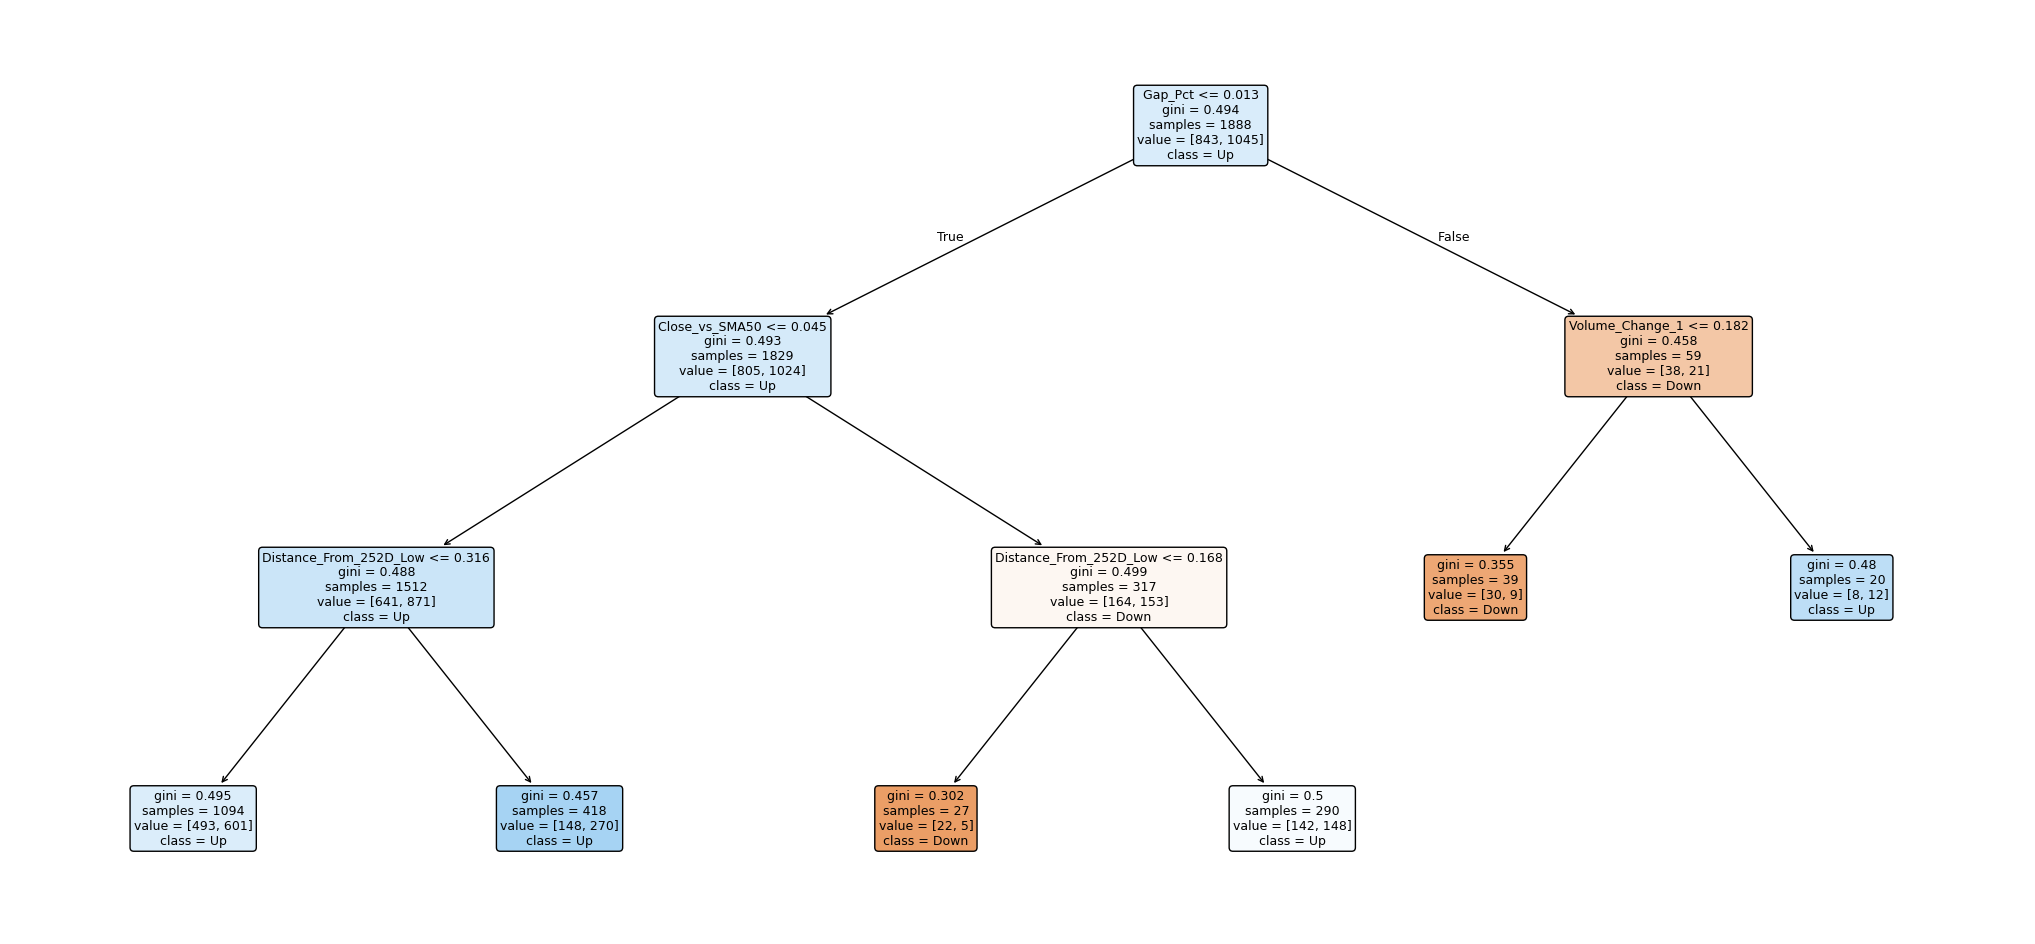

In [33]:
plt.figure(figsize=(26, 12))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Down", "Up"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()

In [34]:
importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance[importance > 0])

Distance_From_252D_Low    0.456558
Gap_Pct                   0.199790
Close_vs_SMA50            0.192171
Volume_Change_1           0.151481
dtype: float64


In [35]:
display(Markdown(
    f"""
## Observations:

The Decision Tree model shows a slight improvement. 

It correctly recognized **{predicted_down}** down days, **{correct_down}** of them were correct.

It increased the test accuracy from **{always_up_test_acc:.4f}** to **{tree_accuracy:.4f}**.
"""
))


## Observations:

The Decision Tree model shows a slight improvement. 

It correctly recognized **2** down days, **2** of them were correct.

It increased the test accuracy from **0.5516** to **0.5595**.


## Decision Tree Result

The Decision Tree achieved:

- **Train accuracy:** approximately 57.34%
- **Test accuracy:** approximately 55.95%
- **Predicted Down days:** 2
- **Correct Down predictions:** 2

The tree slightly outperformed Logistic Regression and the Always-Up baseline. Although it identified very few Down days, both warnings were correct.

This was the best result so far and suggested that simple nonlinear thresholds may be more useful than a linear decision boundary.


# Decision Tree Search

A small parameter search is performed over tree depth, minimum leaf size, and minimum split size.

The goal is not simply to maximize training accuracy. The selected model should improve test performance without creating a large gap between training and testing results.


In [36]:
# Search for best Decision Tree
# -----------------------------
results = []

for depth in range(2, 11):
    for leaf in [2, 5, 10, 20, 30, 50, 100]:
        for split in [2, 5, 10, 20, 50]:

            tree = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_leaf=leaf,
                min_samples_split=split,
                random_state=42
            )

            tree.fit(X_train, y_train)

            y_train_pred = tree.predict(X_train)
            y_test_pred = tree.predict(X_test)

            train_acc = accuracy_score(y_train, y_train_pred)
            test_acc = accuracy_score(y_test, y_test_pred)

            cm = confusion_matrix(y_test, y_test_pred)

            correct_down = cm[0, 0]
            predicted_down = (y_test_pred == 0).sum()
            results.append({
                "max_depth": depth,
                "min_samples_leaf": leaf,
                "min_samples_split": split,
                "train_accuracy": train_acc,
                "test_accuracy": test_acc,
                "predicted_down": predicted_down,
                "correct_down": correct_down
            })

results_df = pd.DataFrame(results)

# Sort by best test accuracy
results_df = results_df.sort_values(
    by="test_accuracy",
    ascending=False
)

print(results_df.head(20))

     max_depth  min_samples_leaf  min_samples_split  train_accuracy  \
53           3                20                 20        0.573623   
52           3                20                 10        0.573623   
51           3                20                  5        0.573623   
50           3                20                  2        0.573623   
54           3                20                 50        0.573623   
47           3                10                 10        0.575742   
45           3                10                  2        0.575742   
46           3                10                  5        0.575742   
48           3                10                 20        0.575742   
104          4               100                 50        0.576801   
100          4               100                  2        0.576801   
101          4               100                  5        0.576801   
102          4               100                 10        0.576801   
103   

In [37]:
# Best tree
# -----------------------------
best_params = results_df.iloc[0]

best_tree = DecisionTreeClassifier(
    max_depth=int(best_params["max_depth"]),
    min_samples_leaf=int(best_params["min_samples_leaf"]),
    min_samples_split=int(best_params["min_samples_split"]),
    random_state=42
)

best_tree.fit(X_train, y_train)

y_train_pred = best_tree.predict(X_train)
y_test_pred = best_tree.predict(X_test)

# Pull out best model statistics
predicted_down = int(best_params["predicted_down"])
correct_down = int(best_params["correct_down"])

print("Best Parameters:")
print(best_params)

print(f"\nTrain Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Best Parameters:
max_depth             3.000000
min_samples_leaf     20.000000
min_samples_split    20.000000
train_accuracy        0.573623
test_accuracy         0.559524
predicted_down        2.000000
correct_down          2.000000
Name: 53, dtype: float64

Train Accuracy: 0.5736
Test Accuracy : 0.5595

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.02      0.03       113
           1       0.56      1.00      0.71       139

    accuracy                           0.56       252
   macro avg       0.78      0.51      0.37       252
weighted avg       0.76      0.56      0.41       252


Confusion Matrix:
[[  2 111]
 [  0 139]]


In [38]:
display(Markdown(
    f"""
## Observations:

The best tree just have almost similar accuracy as our original tree, sometimes slightly better.

The best tree model predicted **{predicted_down}** number of down days, **{correct_down}** of them were correct. 

The best tree model has an accuracy of **{accuracy_score(y_test, y_test_pred):.4f}**.

In general, the Decision Tree model is slightly better than Logistic Regression.
"""
))


## Observations:

The best tree just have almost similar accuracy as our original tree, sometimes slightly better.

The best tree model predicted **2** number of down days, **2** of them were correct. 

The best tree model has an accuracy of **0.5595**.

In general, the Decision Tree model is slightly better than Logistic Regression.


The best tree used:

- `max_depth = 3`
- `min_samples_leaf = 20`
- `min_samples_split = 5`

Its test accuracy remained approximately **55.95%**. The result confirms that a small, carefully restricted tree performs better than deeper or more complicated alternatives.


# Random Forest

Random Forest combines many Decision Trees and usually reduces the variance of a single tree. It is tested to determine whether an ensemble can improve the small Decision Tree's performance.


In [39]:
# Random Forest model
# -----------------------------
rf_v5 = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_v5.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_v5 = rf_v5.predict(X_train)
y_test_pred_v5 = rf_v5.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------
train_accuracy_v5 = accuracy_score(y_train, y_train_pred_v5)
test_accuracy_v5 = accuracy_score(y_test, y_test_pred_v5)
always_up_accuracy = (y_test == 1).mean()

cm_v5 = confusion_matrix(y_test, y_test_pred_v5)

correct_down_v5 = cm_v5[0, 0]
predicted_down_v5 = (y_test_pred_v5 == 0).sum()

print("========== Version 5: Random Forest ==========")
print("Train Accuracy:", train_accuracy_v5)
print("Test Accuracy :", test_accuracy_v5)
print("Always Up Accuracy:", always_up_accuracy)

print("\nClassification Report:")
print("\nConfusion Matrix:")
print(cm_v5)

print("\nPrediction Summary:")
print("Predicted Down:", predicted_down_v5)
print("Correctly predicted Down days:", correct_down_v5)

print("\nObservation:")
print(
    f"Version 5 Random Forest predicted {predicted_down_v5} down days, "
    f"and {correct_down_v5} of them were correct. "
    f"The test accuracy changed from {always_up_accuracy:.4f} "
    f"to {test_accuracy_v5:.4f}."
)

========== Version 5: Random Forest ==========
Train Accuracy: 0.6255296610169492
Test Accuracy : 0.5476190476190477
Always Up Accuracy: 0.5515873015873016

Classification Report:

Confusion Matrix:
[[  2 111]
 [  3 136]]

Prediction Summary:
Predicted Down: 5
Correctly predicted Down days: 2

Observation:
Version 5 Random Forest predicted 5 down days, and 2 of them were correct. The test accuracy changed from 0.5516 to 0.5476.


## Random Forest Result

The Random Forest achieved test accuracy of approximately **54.76%**, below the Always-Up baseline.

It predicted five Down days, but only two were correct. Despite its greater complexity, the ensemble did not outperform the single small Decision Tree.


# XGBoost

XGBoost is evaluated in two forms:

1. A more flexible model with greater capacity.
2. A simpler model designed to reduce overfitting.


In [40]:
# Version 6: XGBoost on SP500-only features
# -----------------------------
xgb_v6 = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=1,
    reg_alpha=1,
    reg_lambda=5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_v6.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_train_pred_v6 = xgb_v6.predict(X_train)
y_test_pred_v6 = xgb_v6.predict(X_test)

# -----------------------------
# Accuracy
# -----------------------------
train_accuracy_v6 = accuracy_score(y_train, y_train_pred_v6)
test_accuracy_v6 = accuracy_score(y_test, y_test_pred_v6)
always_up_accuracy = (y_test == 1).mean()

cm_v6 = confusion_matrix(y_test, y_test_pred_v6)

correct_down_v6 = cm_v6[0, 0]
predicted_down_v6 = (y_test_pred_v6 == 0).sum()

print("========== Version 6: XGBoost on SP500-only Features ==========")
print("Train Accuracy:", train_accuracy_v6)
print("Test Accuracy :", test_accuracy_v6)
print("Always Up Accuracy:", always_up_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_v6))

print("\nConfusion Matrix:")
print(cm_v6)

print("\nPrediction Summary:")
print("Predicted Down:", predicted_down_v6)
print("Correctly predicted Down days:", correct_down_v6)

print("\nObservation:")
print(
    f"Version 6 XGBoost predicted {predicted_down_v6} down days, "
    f"and {correct_down_v6} of them were correct. "
    f"The test accuracy changed from {always_up_accuracy:.4f} "
    f"to {test_accuracy_v6:.4f}."
)

========== Version 6: XGBoost on SP500-only Features ==========
Train Accuracy: 0.7955508474576272
Test Accuracy : 0.5079365079365079
Always Up Accuracy: 0.5515873015873016

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.16      0.23       113
           1       0.54      0.79      0.64       139

    accuracy                           0.51       252
   macro avg       0.46      0.48      0.43       252
weighted avg       0.47      0.51      0.45       252


Confusion Matrix:
[[ 18  95]
 [ 29 110]]

Prediction Summary:
Predicted Down: 47
Correctly predicted Down days: 18

Observation:
Version 6 XGBoost predicted 47 down days, and 18 of them were correct. The test accuracy changed from 0.5516 to 0.5079.


## Standard XGBoost Result

The standard XGBoost model achieved approximately:

- **Train accuracy:** 79.92%
- **Test accuracy:** 50.40%

The large difference between training and testing accuracy indicates substantial overfitting. The model performed well below the Always-Up baseline.


## Simpler XGBoost


In [41]:
# Version 7: Simple XGBoost on SP500-only features
# Goal: reduce overfitting
# -----------------------------

xgb_simple_sp500 = XGBClassifier(
    objective="binary:logistic",

    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,

    subsample=0.7,
    colsample_bytree=0.7,

    min_child_weight=10,
    gamma=1,

    reg_alpha=1,
    reg_lambda=10,

    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Train model
xgb_simple_sp500.fit(X_train, y_train)

# Predict
train_pred_simple_sp500 = xgb_simple_sp500.predict(X_train)
test_pred_simple_sp500 = xgb_simple_sp500.predict(X_test)

# Accuracy
train_accuracy_simple_sp500 = accuracy_score(y_train, train_pred_simple_sp500)
test_accuracy_simple_sp500 = accuracy_score(y_test, test_pred_simple_sp500)
always_up_accuracy = (y_test == 1).mean()

cm_simple_sp500 = confusion_matrix(y_test, test_pred_simple_sp500)

predicted_down_simple_sp500 = (test_pred_simple_sp500 == 0).sum()
correct_down_simple_sp500 = cm_simple_sp500[0, 0]

print("========== Version 7: Simple XGBoost on SP500-only Features ==========")
print("Train Accuracy:", train_accuracy_simple_sp500)
print("Test Accuracy :", test_accuracy_simple_sp500)
print("Always Up Accuracy:", always_up_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, test_pred_simple_sp500))

print("\nConfusion Matrix:")
print(cm_simple_sp500)

print("\nPrediction Summary:")
print("Predicted Down:", predicted_down_simple_sp500)
print("Correctly predicted Down days:", correct_down_simple_sp500)

print("\nObservation:")
print(
    f"Simple XGBoost predicted {predicted_down_simple_sp500} down days, "
    f"and {correct_down_simple_sp500} of them were correct. "
    f"The test accuracy changed from {always_up_accuracy:.4f} "
    f"to {test_accuracy_simple_sp500:.4f}."
)

========== Version 7: Simple XGBoost on SP500-only Features ==========
Train Accuracy: 0.5889830508474576
Test Accuracy : 0.5436507936507936
Always Up Accuracy: 0.5515873015873016

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.02      0.03       113
           1       0.55      0.97      0.70       139

    accuracy                           0.54       252
   macro avg       0.44      0.49      0.37       252
weighted avg       0.45      0.54      0.40       252


Confusion Matrix:
[[  2 111]
 [  4 135]]

Prediction Summary:
Predicted Down: 6
Correctly predicted Down days: 2

Observation:
Simple XGBoost predicted 6 down days, and 2 of them were correct. The test accuracy changed from 0.5516 to 0.5437.


The simpler XGBoost model reduced the training accuracy, but test accuracy remained only approximately **54.37%**, still below the baseline.

Reducing complexity helped control overfitting but did not create meaningful predictive improvement.


# Model Comparison

| Model | Approximate Test Accuracy | Main Behavior |
|---|---:|---|
| Always Up baseline | 55.16% | Predicts every day as Up |
| Logistic Regression: multi-day returns | 55.16% | Predicts all Up |
| Logistic Regression: lagged returns | 55.56% | Predicts one correct Down day |
| Best lag-only Logistic Regression | 55.95% | Small improvement |
| Lasso Logistic Regression | Near baseline | All coefficients become zero |
| Ridge Logistic Regression | Near baseline | Predicts almost all Up |
| Elastic Net Logistic Regression | Near baseline | Predicts almost all Up |
| Small Decision Tree | 55.95% | Best interpretable nonlinear model |
| Random Forest | 54.76% | Below baseline |
| Standard XGBoost | 50.40% | Strong overfitting |
| Simpler XGBoost | 54.37% | Below baseline |

The exact results may change slightly when the notebook is rerun because Yahoo Finance may update adjusted historical data or append new trading days.


# Discussion

Several important findings emerge from this experiment.

First, Logistic Regression produced only a very small improvement over always predicting Up. Adding short-term lagged returns helped slightly, but the model still predicted almost every test observation as Up.

Second, Lasso, Ridge, and Elastic Net did not solve the problem. Lasso removed all features, while Ridge and Elastic Net continued to favor the majority class.

Third, the small Decision Tree performed better than the more complicated Random Forest and XGBoost models. This suggests that model complexity is not the main limitation.

The more likely explanation is that the current SPY-only feature set contains insufficient predictive information about the next day's direction. More complex models cannot reliably extract a signal that is not present in the predictors, and may instead fit noise.


# Limitations

- The test set contains only the most recent 252 trading days.
- Overall accuracy is heavily influenced by the market's natural tendency to rise more often than it falls.
- Most models predict very few Down days, making class-specific evaluation important.
- The features use only SPY data and do not include broader market information.
- Hyperparameter searches are limited and do not guarantee a globally optimal model.
- The experiment does not include transaction costs, slippage, or a trading strategy.
- A small increase over the baseline may not remain stable in a different market period.


# Final Conclusion

Experiment 2 reformulated stock forecasting as a next-day Up/Down classification problem using only SPY price, candlestick, volume, and technical-indicator features.

Logistic Regression produced a slight improvement of approximately 0.5% to 1% over always predicting Up in its stronger configurations. It predicted only a small number of Down days, but those warnings were often correct.

Lasso eliminated all coefficients and predicted the majority class. Ridge and Elastic Net also predicted almost every day as Up. Random Forest did not improve upon the small Decision Tree, and XGBoost frequently overfit the training data while performing below the baseline on the test set.

The best model was a small Decision Tree. However, its improvement remained modest. The more complex models did not outperform it.

This suggests that the main problem may not be that the models are too simple. Instead, the current SPY-only features may not contain enough predictive information about tomorrow's market direction. Improving or expanding the available information may therefore be more useful than continuing to increase model complexity.


# Next Experiment

The next experiment investigates whether broader market information can improve SPY direction prediction.

In addition to SPY, the feature set will include:

- VIX volatility information
- QQQ technology-market information
- TNX Treasury-yield information
- Bitcoin cryptocurrency-market information

The objective is to determine whether these cross-market variables provide new predictive information beyond what is already contained in SPY.
